### Part A: Limitations of Simple Neural Architectures

In [109]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

(500, 2)
[0 1]


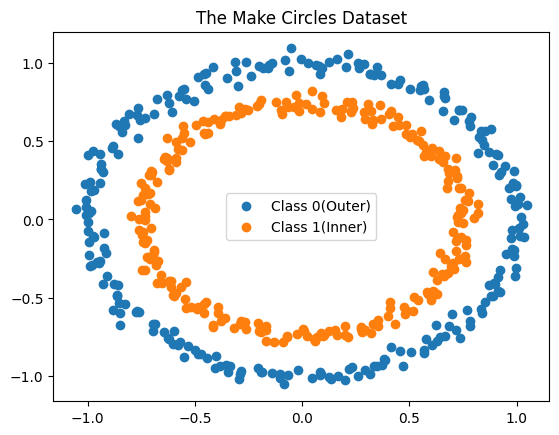

In [110]:
circles=make_circles(n_samples=500,noise=0.03,factor=0.75,random_state=42)
X=circles[0]
y=circles[1]
print(X.shape)
print(np.unique(y))

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

plt.scatter(X[y==0,0],X[y==0,1],label='Class 0(Outer)')
plt.scatter(X[y==1,0],X[y==1,1],label='Class 1(Inner)')
plt.legend()
plt.title("The Make Circles Dataset")
plt.show()

In [111]:
class Perceptron:
    def __init__(self,n_iter,learning_rate=0.01):
        self.lr=learning_rate
        self.activation_func = lambda x: np.where(x >= 0, 1, 0)
        self.weights = None
        self.bias = None
        self.n_iter=n_iter
        
    def fit(self,X,y):
        self.weights = np.zeros(X.shape[1])
        self.bias = 0
        for _ in range(self.n_iter):
            for idx,x_i in enumerate(X):
                output=np.dot(self.weights,x_i)+self.bias
                y_pred=self.activation_func(output)
                update=self.lr*(y[idx]-y_pred)
                self.weights+=update*x_i
                self.bias+=update
    def predict(self,X):
        output=np.dot(X,self.weights)+self.bias
        return self.activation_func(output)


Test Accuracy: 0.46
Test Accuracy: 0.4066666666666667
Test Accuracy: 0.46
Test Accuracy: 0.41333333333333333
Test Accuracy: 0.4533333333333333


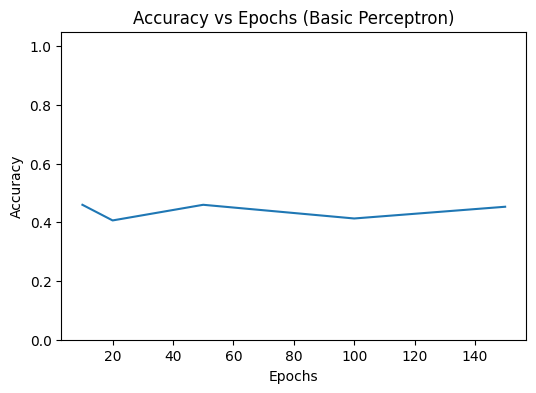

In [112]:
epochs=[10,20,50,100,150]
best_model=None
best_acc=-1
Perceptron_acc=[]
for n_iter in epochs:
    model=Perceptron(n_iter=n_iter)
    model.fit(X_train,y_train)

    y_pred=model.predict(X_test)
    acc=accuracy_score(y_test,y_pred)
    Perceptron_acc.append(acc)
    if(best_acc<acc):
        best_acc=acc
        best_model=model
    print("Test Accuracy:", acc)

plt.figure(figsize=(6,4))
plt.plot(epochs, Perceptron_acc)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.title("Accuracy vs Epochs (Basic Perceptron)")
plt.show()


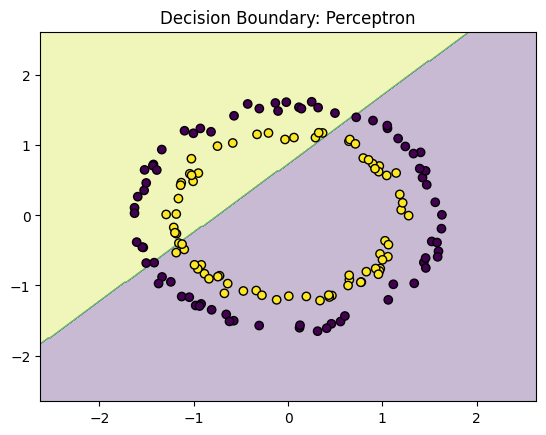

In [113]:
def plot_decision_boundary_unified(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    if hasattr(model, "predict"):
        Z = model.predict(grid)
    else:
        Z = model.forward(grid)

    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k")
    plt.title(title)
    plt.show()

plot_decision_boundary_unified(
    best_model,
    X_test,
    y_test,
    title="Decision Boundary: Perceptron"
)


### Part B: Improving Performance Using Advanced MLP Architectures

##### Step 1:Increasing Network Depth

In [114]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1,1)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1,1)


In [148]:
def step(x):
    return np.where(x >= 0, 1, 0)

class StepMLP_2Hidden:
    def __init__(self, lr=0.01, epochs=50):
        self.lr = lr
        self.epochs = epochs

        self.W1 = np.random.randn(2, 16)
        self.b1 = np.zeros(16)

        self.W2 = np.random.randn(16, 8)
        self.b2 = np.zeros(8)

        self.W3 = np.random.randn(8, 1)
        self.b3 = 0

    def forward(self, X):
        h1 = step(np.dot(X, self.W1) + self.b1)
        h2 = step(np.dot(h1, self.W2) + self.b2)
        out = step(np.dot(h2, self.W3) + self.b3)
        return out.flatten()

    def fit(self, X, y):
        for _ in range(self.epochs):
            for i in range(len(X)):
                y_pred = self.forward(X[i:i+1])[0]
                error = y[i] - y_pred
                self.W3 += self.lr * error
                self.b3 += self.lr * error


Epochs = 10, Accuracy = 0.4800
Epochs = 20, Accuracy = 0.5067
Epochs = 50, Accuracy = 0.5133
Epochs = 100, Accuracy = 0.5333
Epochs = 150, Accuracy = 0.5333


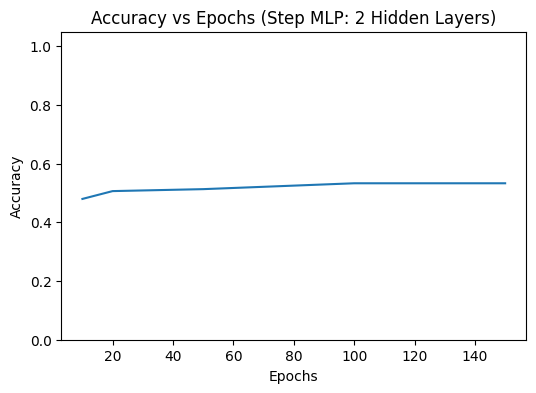

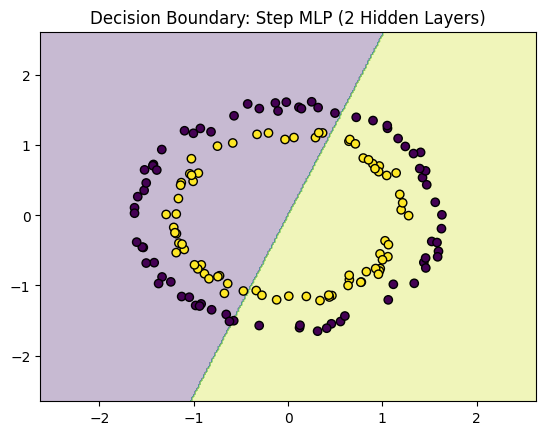

In [149]:
epochs = [10,20,50,100,150]
min_acc=-1
step_mlp_2=None
MLP2_Step_acc=[]
for e in epochs:
    model = StepMLP_2Hidden(lr=0.01, epochs=e)
    model.fit(X_train, y_train)

    y_pred = model.forward(X_test)
    acc = accuracy_score(y_test, y_pred)
    MLP2_Step_acc.append(acc)
    if(acc>min_acc):
        min_acc=acc
        step_mlp_2=model
    print(f"Epochs = {e}, Accuracy = {acc:.4f}")

plt.figure(figsize=(6,4))
plt.plot(epochs, MLP2_Step_acc)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.title("Accuracy vs Epochs (Step MLP: 2 Hidden Layers)")
plt.show()


plot_decision_boundary_unified(
    step_mlp_2,
    X_test,
    y_test,
    title="Decision Boundary: Step MLP (2 Hidden Layers)"
)


In [145]:
class StepMLP_3Hidden:
    def __init__(self, lr=0.01,epochs=50):
        self.lr = lr
        self.epochs = epochs

        self.W1 = np.random.randn(2, 32)
        self.b1 = np.zeros(32)

        self.W2 = np.random.randn(32, 16)
        self.b2 = np.zeros(16)

        self.W3 = np.random.randn(16, 8)
        self.b3 = np.zeros(8)

        self.W4 = np.random.randn(8, 1)
        self.b4 = 0

    def forward(self, X):
        h1 = step(np.dot(X, self.W1) + self.b1)
        h2 = step(np.dot(h1, self.W2) + self.b2)
        h3 = step(np.dot(h2, self.W3) + self.b3)
        out = step(np.dot(h3, self.W4) + self.b4)
        return out.flatten()

    def fit(self, X, y):
        for _ in range(self.epochs):
            for i in range(len(X)):
                y_pred = self.forward(X[i:i+1])[0]
                error = y[i] - y_pred
                self.W4 += self.lr * error
                self.b4 += self.lr * error


Epochs = 10, Accuracy = 0.5133
Epochs = 20, Accuracy = 0.5067
Epochs = 50, Accuracy = 0.5000
Epochs = 100, Accuracy = 0.5400
Epochs = 150, Accuracy = 0.4800


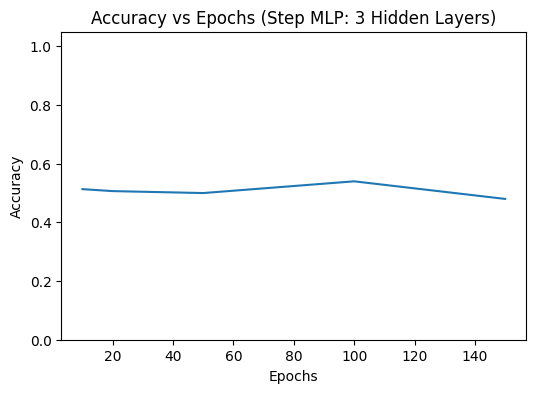

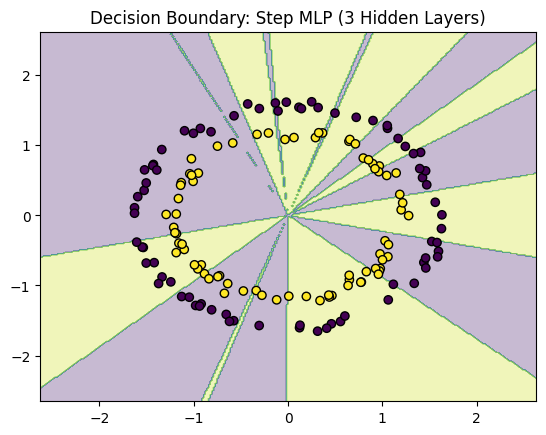

In [146]:
min_acc=-1
step_mlp_3=None
MLP3_Step_acc=[]
for e in epochs:
    model = StepMLP_3Hidden(lr=0.01, epochs=e)
    model.fit(X_train, y_train)

    y_pred = model.forward(X_test)
    acc = accuracy_score(y_test, y_pred)
    MLP3_Step_acc.append(acc)
    if(acc>min_acc):
        min_acc=acc
        step_mlp_3=model
    print(f"Epochs = {e}, Accuracy = {acc:.4f}")

plt.figure(figsize=(6,4))
plt.plot(epochs, MLP3_Step_acc)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.title("Accuracy vs Epochs (Step MLP: 3 Hidden Layers)")
plt.show()


plot_decision_boundary_unified(
    step_mlp_3,
    X_test,
    y_test,
    title="Decision Boundary: Step MLP (3 Hidden Layers)"
)


##### Step 2: Effect of Non-Linear Activation Functions

In [119]:
class SigmoidMLP2(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16),
            nn.Sigmoid(),
            nn.Linear(16, 8),
            nn.Sigmoid(),
            nn.Linear(8, 1)   
        )

    def forward(self, x):
        return self.net(x)


class ReLUMLP2(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)   
        )

    def forward(self, x):
        return self.net(x)

class SigmoidMLP3(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.Sigmoid(),
            nn.Linear(32, 16),
            nn.Sigmoid(),
            nn.Linear(16, 8),
            nn.Sigmoid(),
            nn.Linear(8,1)
        )

    def forward(self, x):
        return self.net(x)


class ReLUMLP3(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
        )

    def forward(self, x):
        return self.net(x)



In [120]:
def train_model(model, X, y, epochs, lr=0.01):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    losses = []
    grad_norms=[]
    for epoch in range(epochs):
        optimizer.zero_grad()
        logits = model(X)         
        loss = criterion(logits, y)  
        loss.backward()
        total_norm = 0.0
        for p in model.parameters():
            if p.grad is not None:
                total_norm += p.grad.norm().item()
        grad_norms.append(total_norm)
        optimizer.step()
        losses.append(loss.item())

    return losses,grad_norms


In [121]:
best_sigmoid_acc = -1
best_sigmoid_model = None
best_sigmoid_epoch = None
Sigmoid_MLP2_acc=[]
loss_Sig_MLP2=[]
grad_norm_Sig_MLP2=[]
for e in epochs:
    model = SigmoidMLP2()
    loss_Sig_MLP2,grad_norm_Sig_MLP2=train_model(
        model,
        X_train_t,
        y_train_t,
        epochs=e,
        lr=0.05
    )

    with torch.no_grad():
        preds = (model(X_test_t) >= 0.5).int()
        acc = accuracy_score(y_test, preds.numpy())
        Sigmoid_MLP2_acc.append(acc)

    print(f"Sigmoid | Epochs = {e}, Accuracy = {acc:.4f}")

    if acc > best_sigmoid_acc:
        best_sigmoid_acc = acc
        best_sigmoid_model = model
        best_sigmoid_epoch = e

best_relu_acc = -1
best_relu_model = None
best_relu_epoch = None
ReLU_MLP2_acc=[]
loss_ReLU_MLP2=[]
grad_norm_ReLU_MLP2=[]
for e in epochs:
    model = ReLUMLP2()
    loss_ReLU_MLP2,grad_norm_ReLU_MLP2=train_model(
        model,
        X_train_t,
        y_train_t,
        epochs=e,
        lr=0.05
    )

    with torch.no_grad():
        preds = (model(X_test_t) >= 0.5).int()
        acc = accuracy_score(y_test, preds.numpy())
        ReLU_MLP2_acc.append(acc)

    print(f"ReLU | Epochs = {e}, Accuracy = {acc:.4f}")

    if acc > best_relu_acc:
        best_relu_acc = acc
        best_relu_model = model
        best_relu_epoch = e



Sigmoid | Epochs = 10, Accuracy = 0.5000
Sigmoid | Epochs = 20, Accuracy = 0.5000
Sigmoid | Epochs = 50, Accuracy = 0.6600
Sigmoid | Epochs = 100, Accuracy = 1.0000
Sigmoid | Epochs = 150, Accuracy = 0.9933
ReLU | Epochs = 10, Accuracy = 0.6333
ReLU | Epochs = 20, Accuracy = 1.0000
ReLU | Epochs = 50, Accuracy = 1.0000
ReLU | Epochs = 100, Accuracy = 1.0000
ReLU | Epochs = 150, Accuracy = 1.0000



Best Sigmoid Model:
Epochs = 100, Accuracy = 1.0000

Best ReLU Model:
Epochs = 20, Accuracy = 1.0000


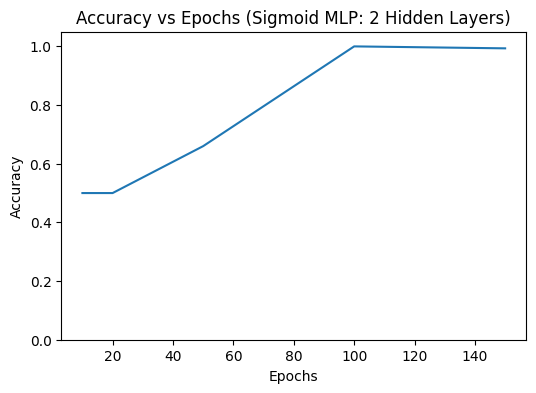

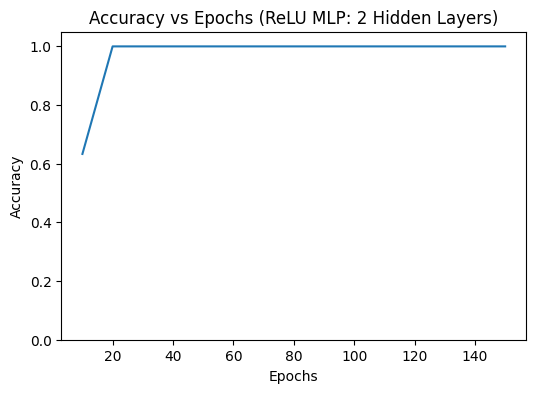

In [122]:
print("\nBest Sigmoid Model:")
print(f"Epochs = {best_sigmoid_epoch}, Accuracy = {best_sigmoid_acc:.4f}")

print("\nBest ReLU Model:")
print(f"Epochs = {best_relu_epoch}, Accuracy = {best_relu_acc:.4f}")

plt.figure(figsize=(6,4))
plt.plot(epochs, Sigmoid_MLP2_acc)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.title("Accuracy vs Epochs (Sigmoid MLP: 2 Hidden Layers)")
plt.show()

plt.figure(figsize=(6,4))
plt.plot(epochs, ReLU_MLP2_acc)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.title("Accuracy vs Epochs (ReLU MLP: 2 Hidden Layers)")
plt.show()

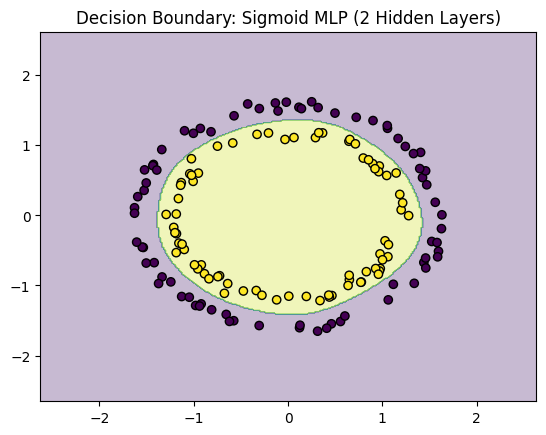

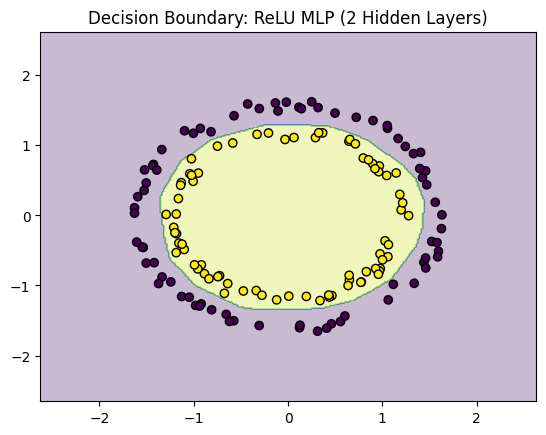

In [123]:
def plot_decision_boundary_torch(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_t = torch.tensor(grid, dtype=torch.float32)

    with torch.no_grad():
        Z = model(grid_t)
        Z = (Z >= 0.5).int().numpy()

    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    plt.title(title)
    plt.show()

plot_decision_boundary_torch(
    best_sigmoid_model,
    X_test,
    y_test,
    title="Decision Boundary: Sigmoid MLP (2 Hidden Layers)"
)

plot_decision_boundary_torch(
    best_relu_model,
    X_test,
    y_test,
    title="Decision Boundary: ReLU MLP (2 Hidden Layers)"
)


In [132]:
best_sigmoid_acc = -1
best_sigmoid_model = None
best_sigmoid_epoch = None
Sigmoid_MLP3_acc=[]
loss_Sig_MLP3=[]
grad_norm_Sig_MLP3=[]
for e in epochs:
    model = SigmoidMLP3()
    loss_Sig_MLP3,grad_norm_Sig_MLP3=train_model(
        model,
        X_train_t,
        y_train_t,
        epochs=e,
        lr=0.05
    )

    with torch.no_grad():
        preds = (model(X_test_t) >= 0.5).int()
        acc = accuracy_score(y_test, preds.numpy())
        Sigmoid_MLP3_acc.append(acc)

    print(f"Sigmoid | Epochs = {e}, Accuracy = {acc:.4f}")

    if acc > best_sigmoid_acc:
        best_sigmoid_acc = acc
        best_sigmoid_model = model
        best_sigmoid_epoch = e

best_relu_acc = -1
best_relu_model = None
best_relu_epoch = None
ReLU_MLP3_acc=[]
loss_ReLU_MLP3=[]
grad_norm_ReLU_MLP3=[]
for e in epochs:
    model = ReLUMLP3()
    loss_ReLU_MLP3,grad_norm_Sig_MLP3=train_model(
        model,
        X_train_t,
        y_train_t,
        epochs=e,
        lr=0.05
    )
    print(loss_ReLU_MLP3)
    with torch.no_grad():
        preds = (model(X_test_t) >= 0.5).int()
        acc = accuracy_score(y_test, preds.numpy())
        ReLU_MLP3_acc.append(acc)

    print(f"ReLU | Epochs = {e}, Accuracy = {acc:.4f}")

    if acc > best_relu_acc:
        best_relu_acc = acc
        best_relu_model = model
        best_relu_epoch = e



Sigmoid | Epochs = 10, Accuracy = 0.5000
Sigmoid | Epochs = 20, Accuracy = 0.5000
Sigmoid | Epochs = 50, Accuracy = 0.5000
Sigmoid | Epochs = 100, Accuracy = 1.0000
Sigmoid | Epochs = 150, Accuracy = 1.0000
[0.6970780491828918, 0.6834797263145447, 0.6645553112030029, 0.6307963132858276, 0.5810641646385193, 0.5144554972648621, 0.44000792503356934, 0.36122819781303406, 0.4303206503391266, 0.25026100873947144]
ReLU | Epochs = 10, Accuracy = 0.9733
[0.7007885575294495, 0.6890722513198853, 0.6776100993156433, 0.6548448801040649, 0.6122927665710449, 0.5463120937347412, 0.49711960554122925, 0.42957237362861633, 0.34151411056518555, 0.2665472626686096, 0.22355057299137115, 0.20905634760856628, 0.10891827195882797, 0.10423757135868073, 0.07517539709806442, 0.035968344658613205, 0.04902438446879387, 0.02558319643139839, 0.016299666836857796, 0.012557280249893665]
ReLU | Epochs = 20, Accuracy = 0.9933
[0.7067295908927917, 0.6999467015266418, 0.6939525008201599, 0.685503363609314, 0.67958796024322


Best Sigmoid Model:
Epochs = 100, Accuracy = 1.0000

Best ReLU Model:
Epochs = 20, Accuracy = 1.0000


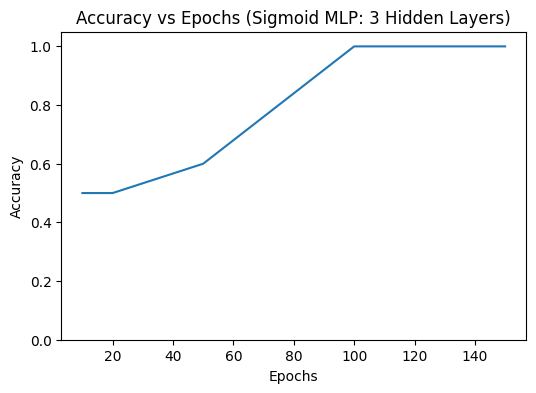

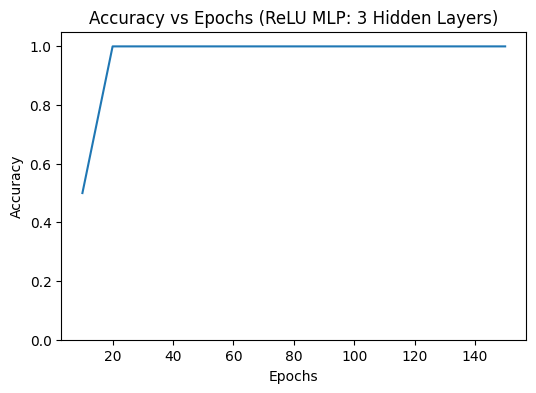

In [125]:
print("\nBest Sigmoid Model:")
print(f"Epochs = {best_sigmoid_epoch}, Accuracy = {best_sigmoid_acc:.4f}")

print("\nBest ReLU Model:")
print(f"Epochs = {best_relu_epoch}, Accuracy = {best_relu_acc:.4f}")

plt.figure(figsize=(6,4))
plt.plot(epochs, Sigmoid_MLP3_acc)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.title("Accuracy vs Epochs (Sigmoid MLP: 3 Hidden Layers)")
plt.show()

plt.figure(figsize=(6,4))
plt.plot(epochs, ReLU_MLP3_acc)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.title("Accuracy vs Epochs (ReLU MLP: 3 Hidden Layers)")
plt.show()

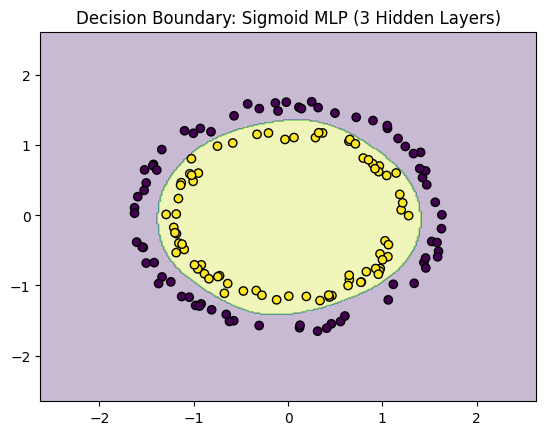

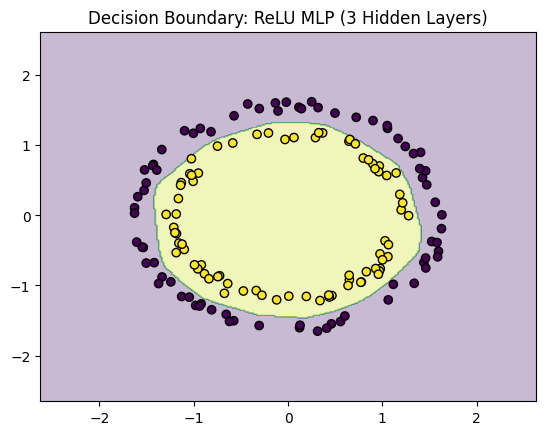

In [126]:
def plot_decision_boundary_torch(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_t = torch.tensor(grid, dtype=torch.float32)

    with torch.no_grad():
        Z = model(grid_t)
        Z = (Z >= 0.5).int().numpy()

    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    plt.title(title)
    plt.show()

plot_decision_boundary_torch(
    best_sigmoid_model,
    X_test,
    y_test,
    title="Decision Boundary: Sigmoid MLP (3 Hidden Layers)"
)

plot_decision_boundary_torch(
    best_relu_model,
    X_test,
    y_test,
    title="Decision Boundary: ReLU MLP (3 Hidden Layers)"
)


##### Step 3: Convergence Analysis 

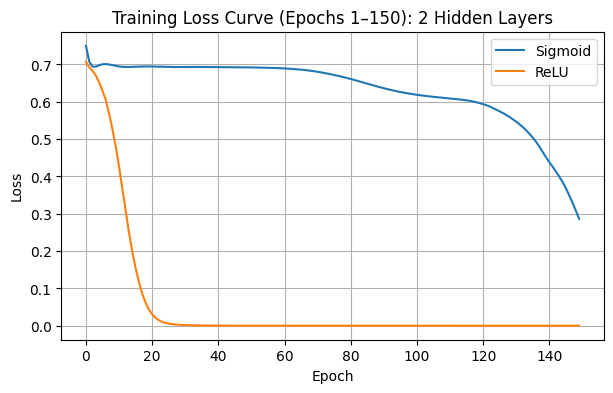

In [139]:
plt.figure(figsize=(7,4))
plt.plot(loss_Sig_MLP2, label="Sigmoid")
plt.plot(loss_ReLU_MLP2, label="ReLU")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve (Epochs 1–150): 2 Hidden Layers")
plt.legend()
plt.grid(True)
plt.show()


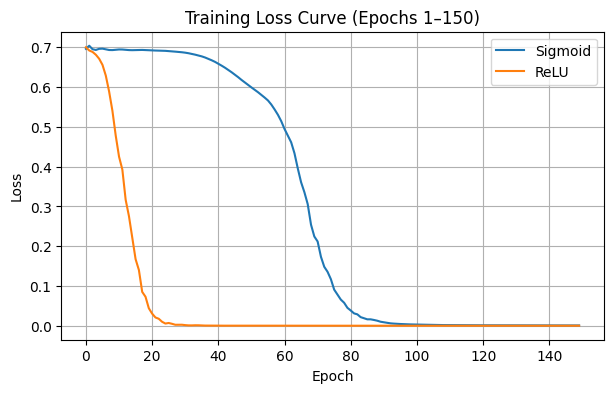

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(loss_Sig_MLP3, label="Sigmoid")
plt.plot(loss_ReLU_MLP3, label="ReLU")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve (Epochs 1–150) 3 Hidden Layers")
plt.legend()
plt.grid(True)
plt.show()


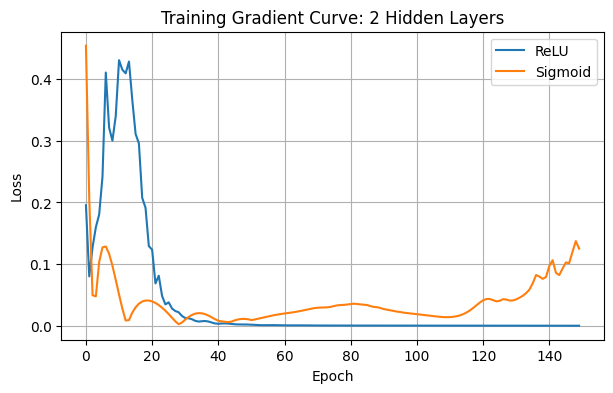

In [142]:
plt.figure(figsize=(7,4))
plt.plot(grad_norm_ReLU_MLP2, label="ReLU")
plt.plot(grad_norm_Sig_MLP2, label="Sigmoid")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Gradient Curve: 2 Hidden Layers")
plt.legend()
plt.grid(True)
plt.show()


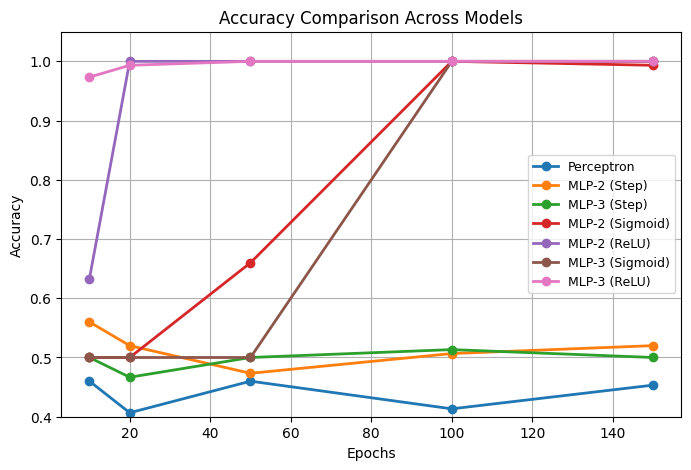

In [144]:
plt.figure(figsize=(8,5))

plt.plot(epochs, Perceptron_acc, marker='o', linewidth=2, label="Perceptron")
plt.plot(epochs, MLP2_Step_acc, marker='o', linewidth=2, label="MLP-2 (Step)")
plt.plot(epochs, MLP3_Step_acc, marker='o', linewidth=2, label="MLP-3 (Step)")
plt.plot(epochs, Sigmoid_MLP2_acc, marker='o', linewidth=2, label="MLP-2 (Sigmoid)")
plt.plot(epochs, ReLU_MLP2_acc, marker='o', linewidth=2, label="MLP-2 (ReLU)")
plt.plot(epochs, Sigmoid_MLP3_acc, marker='o', linewidth=2, label="MLP-3 (Sigmoid)")
plt.plot(epochs, ReLU_MLP3_acc, marker='o', linewidth=2, label="MLP-3 (ReLU)")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.ylim(0.4, 1.05)
plt.title("Accuracy Comparison Across Models")
plt.legend(fontsize=9)
plt.grid(True)
plt.show()


### Part C: Comparative Evaluations and Analytics in Report